# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


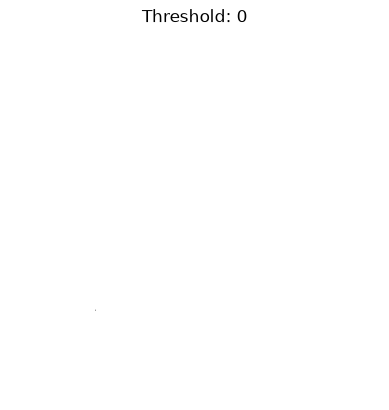

Threshold value: 50


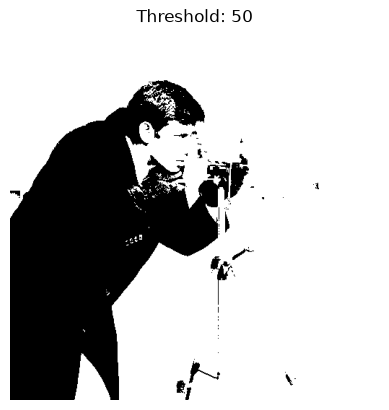

Threshold value: 100


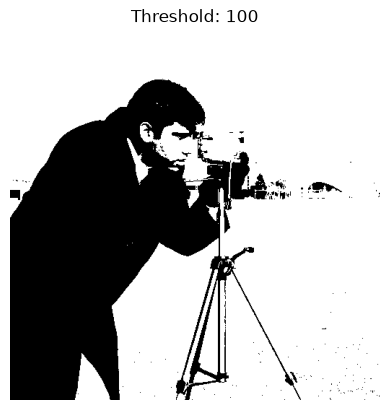

Threshold value: 150


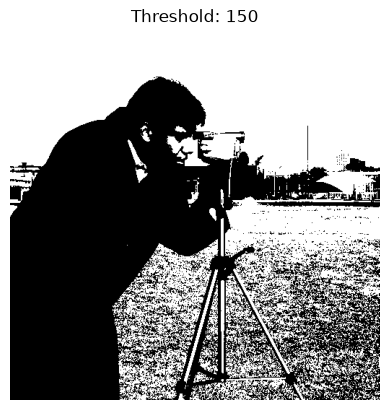

Threshold value: 200


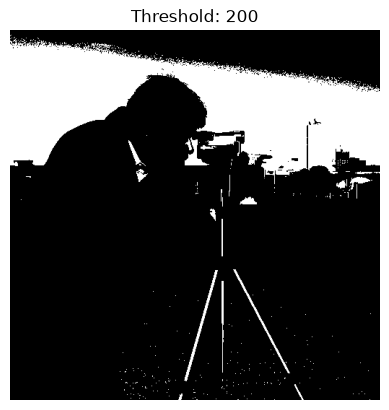

In [3]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

# Load a reliable grayscale cameraman image
img = data.camera()

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    print(f"Threshold value: {threshold_value}")

    plt.imshow(thresh_img, cmap="gray")
    plt.axis("off")
    plt.title(f"Threshold: {threshold_value}")
    plt.show()

Original Image: 


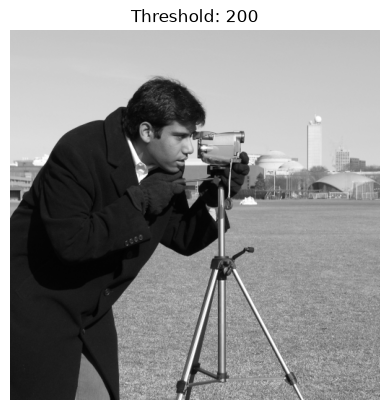

In [4]:
print("Original Image: ")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Threshold: {threshold_value}")
plt.show()

## Histograms

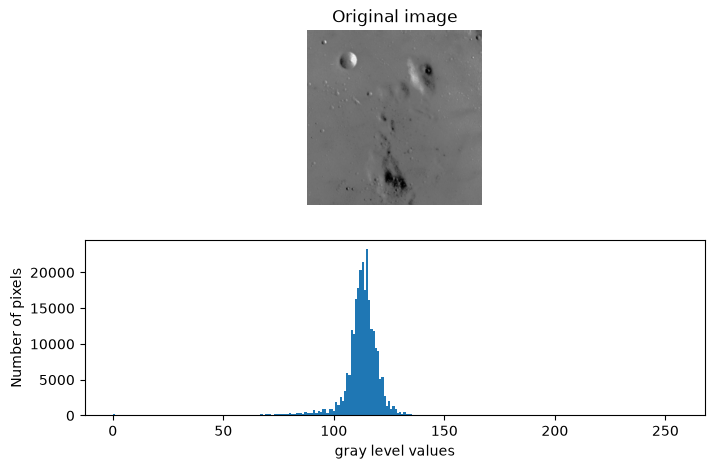

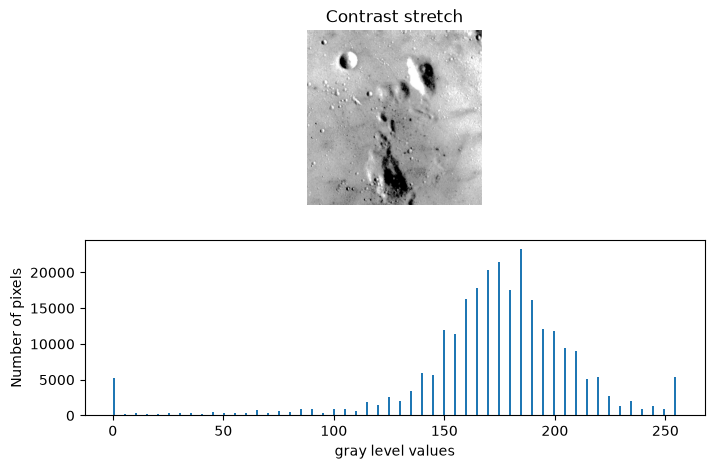

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


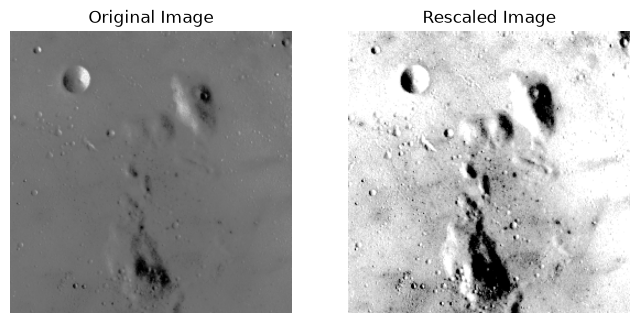

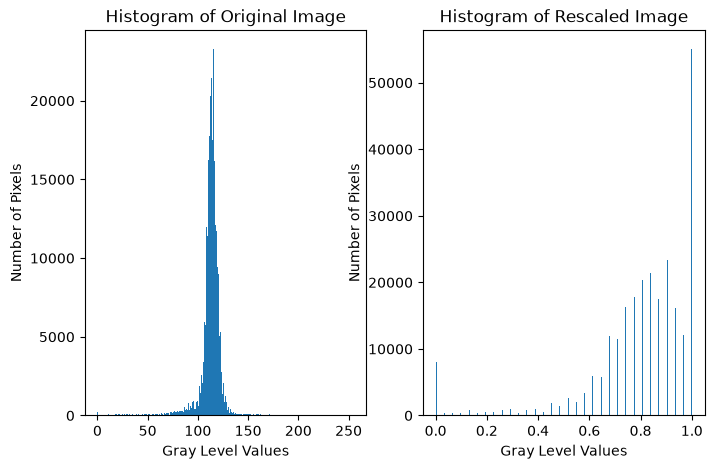

In [ ]:
#TASK 1:  

myimg = data.moon()
#Rescale intensity values to include all the intensities that fall within the 3rd and 80th percentiles
p3, p80 = np.percentile(myimg, [3, 80])
myimg_rescaled = np.clip((myimg - p3) / (p80 - p3), 0, 1)

#Plotting the original and rescaled images
fig = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(myimg, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(myimg_rescaled, cmap='gray')
plt.axis('off')
plt.title('Rescaled Image')
plt.show()

#Plotting the histograms of the original and rescaled images
fig = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.hist(myimg.flat, bins=256, range=(0, 255))
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')
plt.title('Histogram of Original Image')
plt.subplot(1, 2, 2)
plt.hist(myimg_rescaled.flat, bins=256, range=(0, 1))
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')
plt.title('Histogram of Rescaled Image')
plt.show()

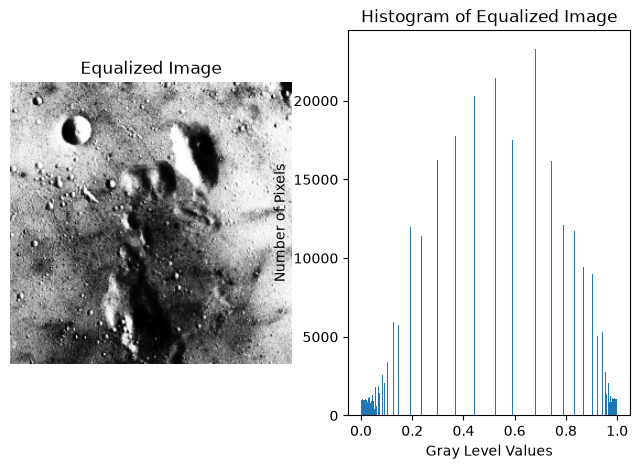

In [ ]:
#TASK 2: 

#Using the exposure.equalize_hist function to flatten the histogram.
myimg_equalized = exposure.equalize_hist(myimg)

#Display the image and the histogram of the image after flattening the histogram.
fig = plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(myimg_equalized, cmap='gray')
plt.axis('off')
plt.title('Equalized Image')
plt.subplot(1, 2, 2)
plt.hist(myimg_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')
plt.title('Histogram of Equalized Image')
plt.show()

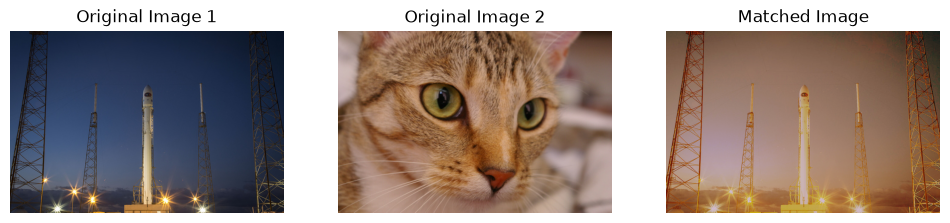

In [ ]:
#TAAK 3: 

my_img2 = data.rocket()
my_img3 = data.chelsea()

#Performing histogram matching on the images to match the histogram of my_img2 to that of my_img3.
matched_img = exposure.match_histograms(my_img2, my_img3, channel_axis=-1)

#Display the original images and the matched image.
fig = plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(my_img2)
plt.axis('off')
plt.title('Original Image 1')
plt.subplot(1, 3, 2)
plt.imshow(my_img3)
plt.axis('off')
plt.title('Original Image 2')
plt.subplot(1, 3, 3)
plt.imshow(matched_img)
plt.axis('off')
plt.title('Matched Image')
plt.show()